# Lightweight Hybrid Learning Framework for Banking Fraud Detection Using Explainable Artificial Intelligence

## 1. Introduction

Banking and credit-card fraud is a major problem in the financial sector. With the increasing number of electronic and online transactions, detecting fraudulent activities accurately and quickly has become important for protecting customers and financial institutions.

Machine Learning can be used to analyze transaction patterns and identify whether a transaction is genuine or fraudulent. However, traditional machine-learning models may require large amounts of computational resources and may be difficult to interpret.

This project proposes a lightweight hybrid machine-learning framework for banking fraud detection. A reduced dataset derived from the official Credit Card Fraud Detection dataset is used to reduce computational requirements. Important transaction features are selected and multiple machine-learning models are implemented and compared for fraud detection.

Explainable Artificial Intelligence (XAI) is also incorporated to understand why the model classifies a transaction as fraudulent or genuine. SHAP is used to identify the contribution of individual features to the model's prediction.

The main goal of this project is to develop an efficient and interpretable fraud-detection system that can classify banking transactions while providing understandable explanations for its predictions.

## 2. Objectives

* To analyze banking transaction data for fraud detection.
* To preprocess and clean the transaction dataset.
* To identify important features for fraud classification.
* To develop machine-learning models for fraud detection.
* To combine suitable models into a hybrid learning approach.
* To evaluate the performance using classification metrics.
* To use Explainable AI to understand the model's predictions.


## 3. DATASET DESCRIPTION

Dataset Name:
Credit Card Fraud Detection Dataset

Source:
Machine Learning Group, Université Libre de Bruxelles (ULB)
and Worldline

Official Dataset:
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Original Records:
284,807

Original Features:
30 input features

Target:
Class

Class 0:
Genuine

Class 1:
Fraud

Project Dataset:
283,726 records

Genuine:
283,253

Fraud:
473

In [3]:
import pandas as pd

df = pd.read_csv("creditcard_preprocessed.csv")

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Dataset shape: (283726, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-0.701082,-0.041687,1.680101,0.976623,-0.247020,0.348012,0.193700,0.084434,0.333534,...,-0.024777,0.383483,-0.177444,0.110157,0.247059,-0.392622,0.333033,-0.065850,0.244200,0
1,-1.996823,0.608792,0.164138,0.109279,0.318998,0.042258,-0.060980,-0.065656,0.072903,-0.231703,...,-0.311372,-0.881454,0.162081,-0.561503,0.321175,0.260854,-0.027154,0.043219,-0.342584,0
2,-1.996802,-0.700336,-0.811337,1.174270,0.270648,-0.366756,1.352655,0.643223,0.210788,-1.381169,...,0.343094,1.065068,1.457772,-1.138484,-0.628161,-0.288861,-0.144325,-0.183824,1.158900,0
3,-1.996802,-0.499064,-0.109972,1.187383,-0.608355,-0.008814,0.937245,0.192079,0.320843,-1.264664,...,-0.149093,0.007299,-0.305465,-1.941446,1.242487,-0.460694,0.154039,0.185687,0.139886,0
4,-1.996781,-0.597606,0.535539,1.025470,0.287092,-0.297036,0.072873,0.481517,-0.228725,0.747917,...,-0.012516,1.101780,-0.220709,0.232904,-0.394800,1.041677,0.550001,0.654234,-0.073813,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-nu

## 4. DATA PREPROCESSING

Data preprocessing is performed to prepare the banking transaction dataset for machine-learning models. The preprocessing process includes checking the initial dataset shape, analyzing missing values, identifying and removing duplicate records, treating missing values where required, checking categorical variables, performing feature scaling, checking the final dataset shape, and ensuring that preprocessing is performed without data leakage.

In [6]:
print("Initial Dataset Shape")
print("---------------------")
print("Number of Records:", df.shape[0])
print("Number of Features:", df.shape[1])
print("Dataset Shape:", df.shape)

Initial Dataset Shape
---------------------
Number of Records: 283726
Number of Features: 31
Dataset Shape: (283726, 31)


The initial dataset shape shows the number of transaction records and features available before preprocessing.

In [7]:
missing_values = df.isnull().sum()

print("Missing Value Analysis")
print("----------------------")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Value Analysis
----------------------
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing Values: 0


The missing-value analysis is performed to identify incomplete observations in the dataset. If the total number of missing values is zero, no missing-value imputation is required.

In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate Analysis")
print("------------------")
print("Duplicate rows in processed dataset:", duplicate_count)
print("Dataset shape after duplicate removal:", df.shape)
print("Duplicate rows after verification:", df.duplicated().sum())


Duplicate Analysis
------------------
Duplicate rows in processed dataset: 0
Dataset shape after duplicate removal: (283726, 31)
Duplicate rows after verification: 0


Duplicate records are removed to prevent repeated transactions from unnecessarily influencing the machine-learning models. The dataset shape after duplicate removal is displayed to show the effect of this preprocessing step.

In [9]:
import numpy as np
from sklearn.impute import SimpleImputer

numeric_columns = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

print("Missing-value treatment completed.")
print("Total missing values after treatment:", df.isnull().sum().sum())

Missing-value treatment completed.
Total missing values after treatment: 0


Median imputation is used for numerical variables if missing values are present. After imputation, the dataset is checked again to confirm that missing values have been treated.

For this dataset, if no missing values were originally present, the imputation step does not change the values.

In [10]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(list(categorical_columns))

if len(categorical_columns) == 0:
    print("\nNo categorical features are present.")
    print("Categorical encoding is not required for this dataset.")
else:
    print("\nCategorical encoding is required for:")
    print(list(categorical_columns))

Categorical Columns:
[]

No categorical features are present.
Categorical encoding is not required for this dataset.


The dataset contains numerical transaction features such as Time, V1 to V28, and Amount. Therefore, categorical encoding is not required for the input features.

The target variable Class is already numerically encoded:

0 = Genuine transaction

1 = Fraudulent transaction

In [11]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (226980, 30)
Testing data shape: (56746, 30)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training data shape: (226980, 30)
Scaled testing data shape: (56746, 30)


In [14]:
scaled_train_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

print("First 5 rows after standardization:")
display(scaled_train_df.head())

print("\nMean of scaled training features:")
print(scaled_train_df.mean().round(4).head())

print("\nStandard deviation of scaled training features:")
print(scaled_train_df.std().round(4).head())

First 5 rows after standardization:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,1.045499,1.147198,-1.042032,-1.428821,-1.817824,0.727198,2.695677,-1.489310,0.735746,-1.152704,...,-0.427196,-0.208573,-0.068205,0.445379,1.130202,-0.420363,-0.331281,0.092782,-0.156193,-0.229434
1,-0.298690,-0.677911,0.991948,0.394668,-0.025642,-0.301198,-0.728240,0.175615,0.629070,-1.156290,...,-0.089833,-0.332248,-1.307141,0.518036,0.851069,-1.367338,-0.554255,-0.049864,0.153831,-0.331197
2,0.678397,0.977654,0.016205,-1.386701,0.092688,0.850613,0.458823,-0.019872,0.154370,0.262056,...,-0.277973,0.405040,1.512732,-0.071350,-2.788905,0.202924,0.015479,0.111329,-0.165820,-0.298809
3,-0.074929,0.927561,0.195261,0.208736,2.739855,0.032003,0.772348,-0.613532,0.199999,0.625478,...,-0.301091,0.190793,0.966846,0.278559,1.160348,-0.407893,-0.021447,-0.049724,-0.119582,-0.289247
4,-1.376728,0.695218,-0.676118,0.363661,-1.090812,-0.882507,0.209618,-1.002620,0.182243,-1.911610,...,-0.477066,-0.473576,-0.878722,0.404329,-0.568164,-0.123705,-0.913882,0.155776,0.037290,-0.261985



Mean of scaled training features:
Time   -0.0
V1      0.0
V2      0.0
V3      0.0
V4     -0.0
dtype: float64

Standard deviation of scaled training features:
Time    1.0
V1      1.0
V2      1.0
V3      1.0
V4      1.0
dtype: float64


Standardization transforms the training features so that they are approximately centered around a mean of 0 with a standard deviation close to 1.

The scaler is fitted only on the training dataset and is then used to transform the testing dataset.

In [15]:
print("Final Dataset Shape After Preprocessing")
print("----------------------------------------")
print("Complete dataset:", df.shape)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Final Dataset Shape After Preprocessing
----------------------------------------
Complete dataset: (283726, 31)
Training features: (226980, 30)
Testing features: (56746, 30)
Training target: (226980,)
Testing target: (56746,)


## Data Leakage Prevention

Data leakage occurs when information from the testing dataset is used during training or preprocessing.

In this project, the dataset is first divided into training and testing datasets. The StandardScaler is fitted only on the training data using `fit_transform()`. The already-fitted scaler is then applied to the testing data using `transform()`.

Therefore, information from the testing dataset is not used to calculate the scaling parameters.

This ensures that the testing data remains unseen during the preprocessing and training process and provides a more reliable evaluation of the machine-learning models.

In [16]:
print("Data Leakage Prevention Check")
print("-----------------------------")

print("Scaler was fitted using training data only.")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining mean after scaling:")
print(np.mean(X_train_scaled, axis=0)[:5].round(4))

print("\nTraining standard deviation after scaling:")
print(np.std(X_train_scaled, axis=0)[:5].round(4))

print("\nTesting data was transformed using the training-fitted scaler.")
print("No test-data fitting was performed.")

Data Leakage Prevention Check
-----------------------------
Scaler was fitted using training data only.
Training data shape: (226980, 30)
Testing data shape: (56746, 30)

Training mean after scaling:
[-0.  0.  0.  0. -0.]

Training standard deviation after scaling:
[1. 1. 1. 1. 1.]

Testing data was transformed using the training-fitted scaler.
No test-data fitting was performed.


# Preprocessing Summary

The dataset was successfully preprocessed for machine-learning model development.

The initial dataset shape was checked and missing values were analyzed. Duplicate records were identified and removed where present. Missing numerical values were treated using median imputation where required.

The dataset contains numerical input features, so categorical encoding was not required. The target variable Class is already represented numerically, with 0 representing genuine transactions and 1 representing fraudulent transactions.

The dataset was divided into training and testing sets using an 80:20 ratio with stratification. Feature standardization was performed using StandardScaler for models that require scaled input.

To prevent data leakage, the scaler was fitted only on the training dataset and subsequently used to transform the testing dataset.

The final dataset shapes and preprocessing results are displayed above.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, relationships, and important patterns present in the banking transaction dataset.

The analysis includes descriptive statistics, target class distribution, important feature distributions, correlation analysis, relevant visualizations, and observations obtained from the data.

In [17]:
print("Descriptive Statistics")
print("----------------------")

display(df.describe())

Descriptive Statistics
----------------------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,2.837260e+05,2.837260e+05,2.837260e+05,283726.000000,2.837260e+05,2.837260e+05,2.837260e+05,2.837260e+05,2.837260e+05,...,2.837260e+05,2.837260e+05,2.837260e+05,2.837260e+05,283726.000000,283726.000000,2.837260e+05,2.837260e+05,2.837260e+05,283726.000000
mean,0.000000,-2.564431e-17,-2.003462e-17,2.564431e-17,0.000000,1.282216e-17,1.923323e-17,1.923323e-17,3.205539e-18,1.282216e-17,...,3.205539e-18,-2.564431e-17,3.205539e-18,6.411078e-18,0.000000,0.000000,3.606231e-18,-4.407616e-18,3.205539e-17,0.001667
std,1.000002,1.000002e+00,1.000002e+00,1.000002e+00,1.000002,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002,1.000002,1.000002e+00,1.000002e+00,1.000002e+00,0.040796
min,-1.996823,-2.895933e+01,-4.415594e+01,-3.203279e+01,-4.016602,-8.260323e+01,-1.964022e+01,-3.548131e+01,-6.209721e+01,-1.226160e+01,...,-4.811386e+01,-1.508956e+01,-7.184198e+01,-4.684150e+00,-19.752075,-5.403358,-5.702547e+01,-4.704087e+01,-3.533268e-01,0.000000
25%,-0.855213,-4.732329e-01,-3.620488e-01,-5.907784e-01,-0.599052,-5.022907e-01,-5.765260e-01,-4.515170e-01,-1.763908e-01,-5.866090e-01,...,-3.148664e-01,-7.489963e-01,-2.595820e-01,-5.856219e-01,-0.608675,-0.678169,-1.829567e-01,-1.626863e-01,-3.309625e-01,0.000000
50%,-0.213108,7.426456e-03,4.134568e-02,1.182157e-01,-0.013635,-4.015609e-02,-2.057379e-01,3.181559e-02,1.929719e-02,-4.655399e-02,...,-4.015703e-02,9.233221e-03,-1.820863e-02,6.737087e-02,0.031677,-0.108538,-7.187408e-04,3.274220e-02,-2.654671e-01,0.000000
75%,0.936942,6.725541e-01,4.885028e-01,6.796321e-01,0.525119,4.432736e-01,2.987636e-01,4.632165e-01,2.769666e-01,5.454844e-01,...,2.577181e-01,7.290881e-01,2.365720e-01,7.257359e-01,0.673228,0.498104,2.260181e-01,2.369592e-01,-4.378088e-02,0.000000
max,1.642362,1.257179e+00,1.339762e+01,6.217985e+00,11.935038,2.527211e+01,5.503507e+01,9.822550e+01,1.696961e+01,1.423708e+01,...,3.757826e+01,1.449606e+01,3.612020e+01,7.569585e+00,14.427362,7.296299,7.987613e+01,1.031847e+02,1.022476e+02,1.000000


The descriptive statistics provide information about the numerical features in the dataset, including count, mean, standard deviation, minimum value, maximum value, and quartiles.

These statistics help in understanding the general distribution and range of the transaction features.

In [18]:
print("Class Distribution")
print("------------------")

class_distribution = df["Class"].value_counts()

print("Genuine transactions:", class_distribution.get(0, 0))
print("Fraudulent transactions:", class_distribution.get(1, 0))

Class Distribution
------------------
Genuine transactions: 283253
Fraudulent transactions: 473


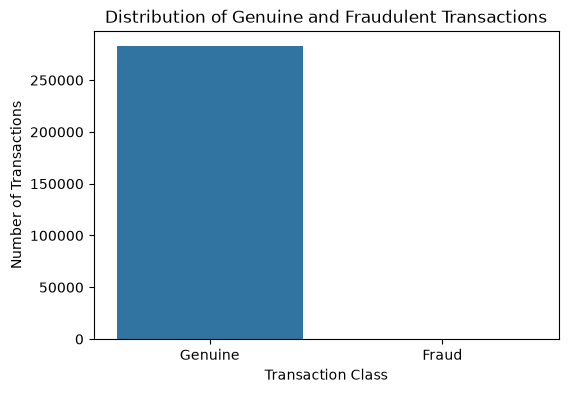

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Distribution of Genuine and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

The class distribution plot shows the number of genuine and fraudulent transactions present in the dataset.

Class 0 represents genuine transactions, while Class 1 represents fraudulent transactions.

The class distribution is important because fraud detection focuses on correctly identifying fraudulent transactions rather than relying only on overall accuracy.

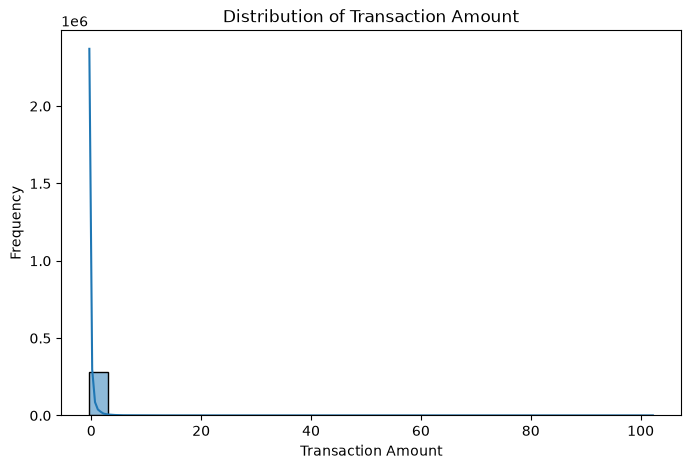

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=30,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

The transaction amount distribution shows how the monetary values of transactions are distributed.

The visualization helps identify the common transaction-value range and possible unusually high or low transaction amounts.

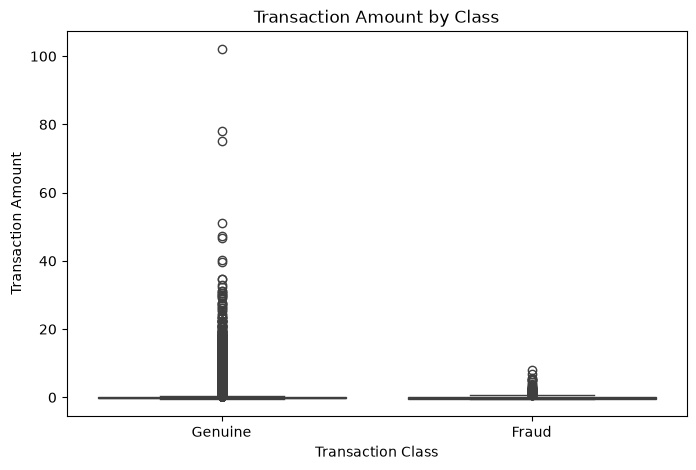

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

The boxplot compares transaction amounts between genuine and fraudulent transactions.

The visualization helps identify differences in the distribution of transaction amounts between the two classes and highlights possible outliers.

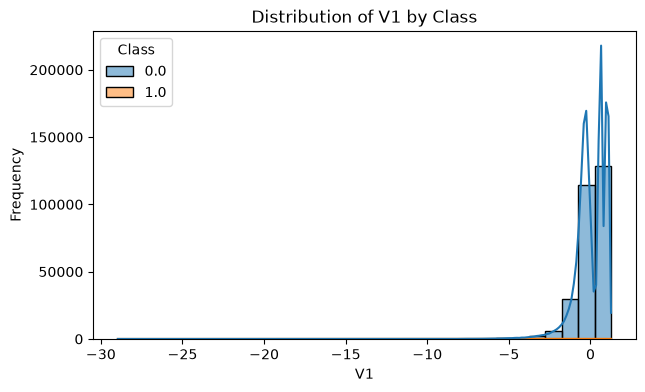

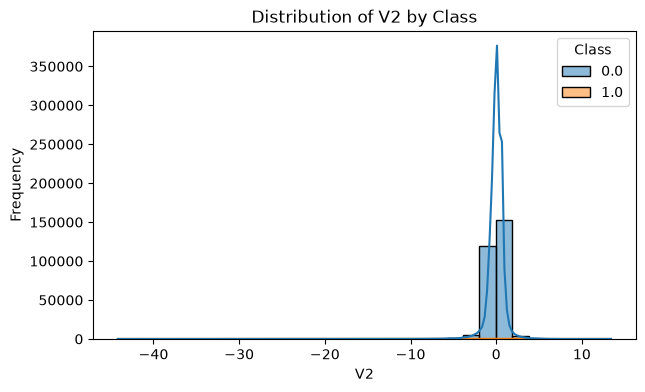

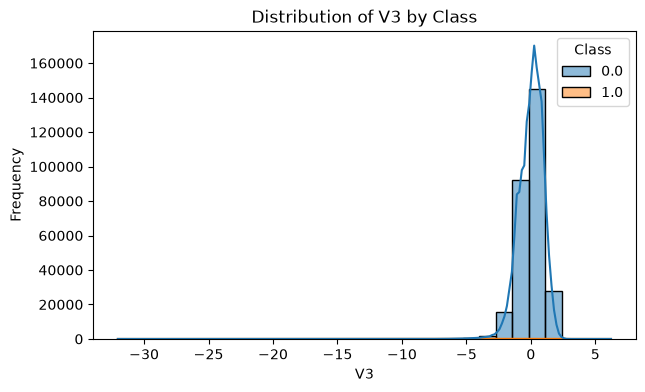

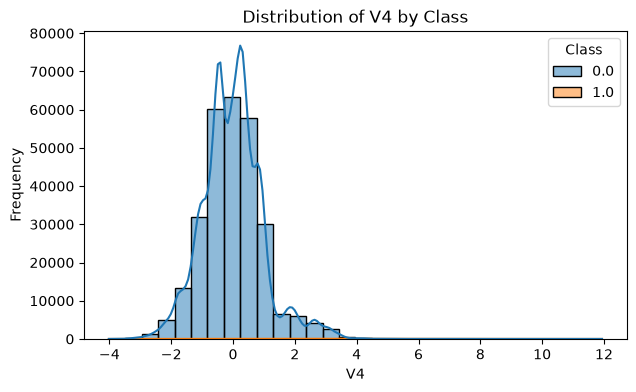

In [22]:
important_features = ["V1", "V2", "V3", "V4"]

for feature in important_features:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

The feature distributions show how selected anonymized transaction features vary across genuine and fraudulent transactions.

The V1 to V28 features are anonymized in the original dataset, so their direct real-world interpretation is not available. However, differences in their distributions between the two classes can provide useful information for machine-learning classification.

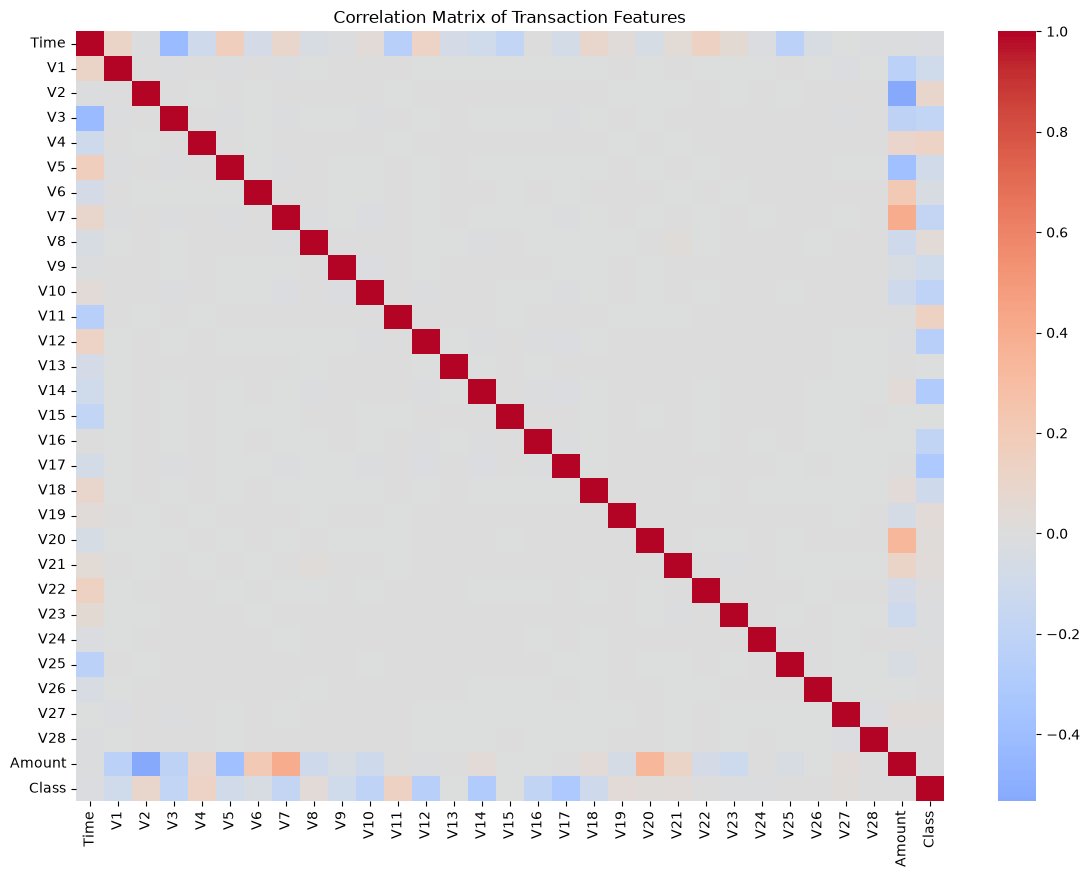

In [23]:
correlation_matrix = df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Transaction Features")

plt.show()

The correlation heatmap shows the relationships between the numerical features and the target variable.

Correlation values closer to 1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values close to 0 indicate a weak linear relationship.

The correlation analysis helps identify relationships between variables and provides useful information for feature selection and model development.

In [24]:
class_correlation = (
    df.corr()["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)

print("Features most strongly associated with Class:")
display(class_correlation.head(10))

Features most strongly associated with Class:


V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

The correlation analysis is used to identify features with stronger linear associations with the target variable Class.

These results can provide an initial indication of potentially useful features. However, correlation alone is not sufficient for selecting the final features because machine-learning models can capture nonlinear relationships as well.

# EDA Observations and Inferences

The exploratory analysis provides the following observations:

- The dataset contains both genuine and fraudulent banking transactions.
- The Class variable represents the target variable, where 0 indicates a genuine transaction and 1 indicates a fraudulent transaction.
- Descriptive statistics provide information about the range, central tendency, and variability of the numerical features.
- The transaction amount distribution shows the variation in monetary values across transactions.
- The boxplot allows the transaction amounts of genuine and fraudulent transactions to be compared.
- The distributions of selected V1 to V28 features show that some feature patterns may differ between genuine and fraudulent transactions.
- The correlation heatmap provides an overview of relationships among the numerical features.
- The correlation of individual features with the Class variable provides useful initial information for feature analysis.
- Since V1 to V28 are anonymized features, their exact real-world meanings cannot be determined from the dataset.
- The EDA results provide a basis for feature selection and machine-learning model development.

# Feature Engineering / Feature Selection

Feature engineering and feature selection are performed to prepare the transaction features for machine-learning modelling.

The original dataset contains the features Time, V1 to V28, and Amount. Since the objective of this project is to develop a lightweight fraud-detection framework, unnecessary features are reduced where appropriate.

No additional domain-specific features are created because the original transaction dataset already contains engineered and anonymized numerical features.

Random Forest feature importance is used to identify the most important features for distinguishing between genuine and fraudulent transactions.

The selected features are then used for model training. Features with lower importance are not selected for the lightweight modelling stage.

In [25]:
print("Original Features")
print("-----------------")
print(X.columns.tolist())

print("\nTotal number of original features:", X.shape[1])

Original Features
-----------------
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Total number of original features: 30


The original input dataset contains 30 features: Time, V1 to V28, and Amount.

The Class column is not included as an input feature because it is the target variable that the models must predict.

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("creditcard_preprocessed.csv")

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Random Forest model
feature_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
feature_model.fit(X_train, y_train)

# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance Ranking")
print("--------------------------")

display(feature_importance)

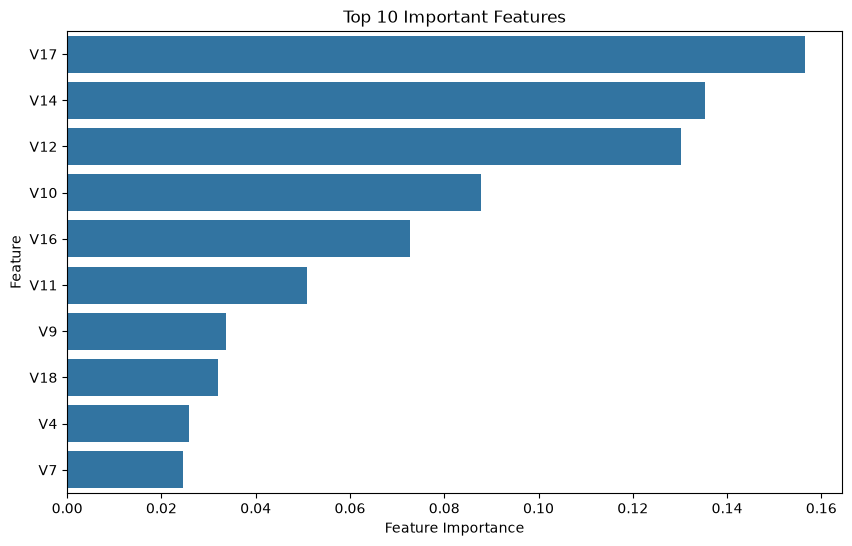

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))

top_features_plot = feature_importance.head(10)

sns.barplot(
    data=top_features_plot,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

The feature-importance plot shows the features that contribute most to the Random Forest classification process.

Features with higher importance values are considered more useful for distinguishing between genuine and fraudulent transactions.

The feature ranking is used to reduce the input feature set and support the lightweight objective of the project.

In [ ]:
selected_features = feature_importance.head(10)["Feature"].tolist()

print("Selected Features for Modelling")
print("-------------------------------")

for i, feature in enumerate(selected_features, start=1):
    print(i, ".", feature)

print("\nTotal selected features:", len(selected_features))

Selected Features for Modelling
-------------------------------
1 . V17
2 . V14
3 . V12
4 . V10
5 . V16
6 . V11
7 . V9
8 . V18
9 . V4
10 . V7

Total selected features: 10


The top 10 features based on Random Forest feature importance are selected for modelling.

The selection is performed to reduce the dimensionality of the input data and reduce unnecessary computational processing while retaining features that provide useful information for fraud classification.

The exact features selected are determined automatically from the dataset rather than being manually assumed.

In [ ]:
X_selected = X[selected_features]

print("Selected Feature Dataset Shape:", X_selected.shape)

print("\nFinal Feature List:")
print(X_selected.columns.tolist())

Selected Feature Dataset Shape: (283726, 10)

Final Feature List:
['V17', 'V14', 'V12', 'V10', 'V16', 'V11', 'V9', 'V18', 'V4', 'V7']


In [ ]:
X_train_selected, X_test_selected, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Selected Training Data Shape:", X_train_selected.shape)
print("Selected Testing Data Shape:", X_test_selected.shape)

Selected Training Data Shape: (226980, 10)
Selected Testing Data Shape: (56746, 10)


In [ ]:
X_train_selected, X_test_selected, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Selected Training Data Shape:", X_train_selected.shape)
print("Selected Testing Data Shape:", X_test_selected.shape)

Selected Training Data Shape: (226980, 10)
Selected Testing Data Shape: (56746, 10)


In [ ]:
from sklearn.preprocessing import StandardScaler
selected_scaler = StandardScaler()

X_train_selected_scaled = selected_scaler.fit_transform(
    X_train_selected
)

X_test_selected_scaled = selected_scaler.transform(
    X_test_selected
)

print("Selected features scaled successfully.")
print("Scaled training data:", X_train_selected_scaled.shape)
print("Scaled testing data:", X_test_selected_scaled.shape)

Selected features scaled successfully.
Scaled training data: (226980, 10)
Scaled testing data: (56746, 10)


Feature scaling is applied to the selected numerical features for models that require standardized input.

The scaler is fitted only on the training data and then applied to the testing data. Therefore, the feature-selection and scaling workflow avoids using testing information during model training.

# Feature Selection Decision

The features are selected based on their Random Forest feature-importance scores.

Features with higher importance are retained because they contribute more strongly to the classification process.

Features with lower importance are not included in the lightweight feature set because removing them can reduce the number of input variables and computational requirements.

The selection does not mean that the rejected features are completely useless. A feature may have a low importance in one model but still contain useful information for another model.

The final feature set is therefore selected specifically for this lightweight machine-learning framework.

# Final Feature List Used for Training

The final feature list used for the lightweight modelling stage is the top 10 features obtained from the Random Forest feature-importance analysis.

The final feature names are displayed automatically in the output above.

This approach ensures that the final feature list is based on the actual dataset and model-derived feature importance rather than manually selecting features.

In [ ]:
selected_features = feature_importance.head(10)["Feature"].tolist()

# Model Building and Training

Machine-learning classification models are implemented to detect fraudulent banking transactions.

The models used in this project are Logistic Regression, Random Forest, and XGBoost. These models represent different learning approaches and are used to compare their ability to distinguish between genuine and fraudulent transactions.

A hybrid learning model is also developed by combining Random Forest and XGBoost using soft voting. The purpose of the hybrid model is to combine the prediction probabilities of the individual models.

The models are trained using the training dataset and evaluated using the testing dataset. Cross-validation is also performed to obtain a more reliable estimate of model performance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Models Implemented

The following classification models are implemented:

- Logistic Regression
- Random Forest
- XGBoost
- Hybrid Model using Random Forest and XGBoost

Logistic Regression is used as a baseline model. Random Forest is an ensemble of decision trees. XGBoost is a gradient-boosting algorithm. The hybrid model combines Random Forest and XGBoost using soft voting.

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_selected_scaled,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(
    X_train_selected,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_selected,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


# Model Configuration and Hyperparameters

The main hyperparameters used for the models are:

Logistic Regression:
- max_iter = 1000
- random_state = 42

Random Forest:
- n_estimators = 100
- max_depth = None
- random_state = 42

XGBoost:
- n_estimators = 100
- max_depth = 4
- learning_rate = 0.1
- random_state = 42
- eval_metric = logloss

These configurations are used as the initial model settings before evaluating and tuning the models.

# Hybrid Learning Model

The hybrid model combines Random Forest and XGBoost using soft voting.

In soft voting, each model produces probabilities for the classes. These probabilities are combined to obtain the final classification decision.

The hybrid approach is included as part of the proposed lightweight framework.

In [ ]:
hybrid_model = VotingClassifier(
    estimators=[
        ("random_forest", rf_model),
        ("xgboost", xgb_model)
    ],
    voting="soft"
)

hybrid_model.fit(
    X_train_selected,
    y_train
)

print("Hybrid model training completed.")

Hybrid model training completed.


# Training Results

The trained models are evaluated on the unseen testing dataset.

Accuracy, precision, recall, and F1-score are calculated to understand the classification performance.

For fraud detection, precision and recall are important because the model should correctly identify fraudulent transactions while reducing incorrect fraud alerts.

In [ ]:
def evaluate_model(model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    return {
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred, zero_division=0),
        "Recall": recall_score(y_test_data, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_data, y_pred, zero_division=0)
    }

lr_results = evaluate_model(
    lr_model,
    X_test_selected_scaled,
    y_test
)

rf_results = evaluate_model(
    rf_model,
    X_test_selected,
    y_test
)

xgb_results = evaluate_model(
    xgb_model,
    X_test_selected,
    y_test
)

hybrid_results = evaluate_model(
    hybrid_model,
    X_test_selected,
    y_test
)

training_results = pd.DataFrame(
    [
        lr_results,
        rf_results,
        xgb_results,
        hybrid_results
    ],
    index=[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Hybrid Model"
    ]
)

display(training_results)

NameError: name 'lr_model' is not defined

The training results show the performance of the implemented classification models on the testing dataset.

The numerical results are obtained directly from the trained models. Accuracy measures the overall correctness of predictions, while precision measures the proportion of predicted fraud cases that are actually fraudulent.

Recall measures the proportion of actual fraudulent transactions detected by the model. F1-score provides a balance between precision and recall.

# Training and Validation Curves

Training and validation curves are useful for studying how model performance changes as the amount of training data increases.

They can help identify whether a model is underfitting or overfitting.

For this project, a learning curve is generated for the Random Forest model.

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X_train_selected,
    y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training F1-score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation F1-score"
)

plt.title("Random Forest Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("F1-score")
plt.legend()
plt.grid()

plt.show()

NameError: name 'RandomForestClassifier' is not defined

The learning curve compares the training and validation F1-scores at different training-set sizes.

The gap between the training and validation curves provides an indication of the model's generalization behavior. A large persistent gap may indicate overfitting, while low performance on both curves may indicate underfitting.

# Cross-Validation

Five-fold cross-validation is performed on the training dataset.

The training data is divided into five parts. In each iteration, four parts are used for training and one part is used for validation.

F1-score is used as the evaluation metric because it considers both precision and recall, which are important for fraud detection.

In [ ]:
models = {
    "Logistic Regression": (
        lr_model,
        X_train_selected_scaled
    ),
    "Random Forest": (
        rf_model,
        X_train_selected
    ),
    "XGBoost": (
        xgb_model,
        X_train_selected
    ),
    "Hybrid Model": (
        hybrid_model,
        X_train_selected
    )
}

cv_results = []

for name, (model, X_data) in models.items():

    scores = cross_val_score(
        model,
        X_data,
        y_train,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean F1-Score": scores.mean(),
        "Std F1-Score": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean F1-Score,Std F1-Score
0,Logistic Regression,0.661017,0.677165,0.696970,0.692913,0.770370,0.699687,0.037555
1,Random Forest,0.838235,0.787879,0.882759,0.842857,0.888889,0.848124,0.036377
2,XGBoost,0.782609,0.764706,0.802721,0.827586,0.863014,0.808127,0.034517
3,Hybrid Model,0.808824,0.772727,0.863014,0.830986,0.888889,0.832888,0.040610


# Cross-Validation Results

The five-fold cross-validation results show the F1-score obtained by each model across different validation folds.

The mean F1-score represents the average performance across the five folds, while the standard deviation indicates how much the performance varies between folds.

Cross-validation provides a more reliable estimate of model performance than relying on a single training-validation split.

# Model Building and Training Summary

Four models were implemented for banking fraud detection: Logistic Regression, Random Forest, XGBoost, and a Hybrid Model combining Random Forest and XGBoost.

The models were configured using suitable hyperparameters and trained using the prepared training data.

Training results were evaluated using accuracy, precision, recall, and F1-score. A learning curve was generated for Random Forest to examine training and validation performance.

Five-fold cross-validation was also performed using F1-score to evaluate the consistency of the models across different validation folds.

The final model selection is performed later based on the complete model evaluation, including confusion matrix, accuracy, precision, recall, F1-score, and ROC-AUC.

# Hyperparameter Tuning

Hyperparameter tuning is performed to improve the performance of the machine learning models by testing different combinations of model parameters. Grid Search with 5-fold cross-validation is used to identify suitable hyperparameter values using only the training data. Random Forest and XGBoost are tuned because they are the main tree-based models used in the proposed hybrid learning framework.

The parameters considered for Random Forest are the number of trees (`n_estimators`) and maximum tree depth (`max_depth`). For XGBoost, the parameters considered are the number of trees (`n_estimators`), maximum tree depth (`max_depth`), and learning rate (`learning_rate`).

The best parameters are selected based on the F1-score obtained through 5-fold cross-validation. The tuned models are then compared with their original versions to observe whether tuning improves their performance.


In [ ]:
# Select top features
top_features = feature_importance["Feature"].head(10).tolist()

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

print("Selected features:")
print(top_features)

print("Training shape:", X_train_selected.shape)
print("Testing shape:", X_test_selected.shape)

Selected features:
['V17', 'V14', 'V12', 'V10', 'V16', 'V11', 'V9', 'V18', 'V4', 'V7']
Training shape: (226980, 10)
Testing shape: (56746, 10)


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Check that Random Forest is available
print("RandomForestClassifier imported successfully")

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_selected, y_train)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(rf_grid.best_score_)

RandomForestClassifier imported successfully


In [ ]:
xgb_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_selected, y_train)

best_xgb = xgb_grid.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(xgb_grid.best_score_)

NameError: name 'XGBClassifier' is not defined

In [ ]:
rf_before = evaluate_model(
    rf_model,
    X_test_selected,
    y_test
)

rf_after = evaluate_model(
    best_rf,
    X_test_selected,
    y_test
)

xgb_before = evaluate_model(
    xgb_model,
    X_test_selected,
    y_test
)

xgb_after = evaluate_model(
    best_xgb,
    X_test_selected,
    y_test
)

tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest",
        "XGBoost",
        "XGBoost"
    ],
    "Version": [
        "Before Tuning",
        "After Tuning",
        "Before Tuning",
        "After Tuning"
    ],
    "Accuracy": [
        rf_before["Accuracy"],
        rf_after["Accuracy"],
        xgb_before["Accuracy"],
        xgb_after["Accuracy"]
    ],
    "Precision": [
        rf_before["Precision"],
        rf_after["Precision"],
        xgb_before["Precision"],
        xgb_after["Precision"]
    ],
    "Recall": [
        rf_before["Recall"],
        rf_after["Recall"],
        xgb_before["Recall"],
        xgb_after["Recall"]
    ],
    "F1-Score": [
        rf_before["F1-Score"],
        rf_after["F1-Score"],
        xgb_before["F1-Score"],
        xgb_after["F1-Score"]
    ]
})

display(tuning_results)

In [ ]:
best_parameters = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Best Parameters": [
        rf_grid.best_params_,
        xgb_grid.best_params_
    ],
    "Best CV F1-Score": [
        rf_grid.best_score_,
        xgb_grid.best_score_
    ]
})

display(best_parameters)

Grid Search with 5-fold cross-validation was used for hyperparameter tuning. Random Forest was tuned using `n_estimators` and `max_depth`, while XGBoost was tuned using `n_estimators`, `max_depth`, and `learning_rate`. The best parameter combinations were selected based on the F1-score. The before-and-after performance table shows the effect of tuning on accuracy, precision, recall, and F1-score. The tuned models can subsequently be used in the final model comparison and evaluation.


# Model Evaluation

The trained classification models are evaluated using the test dataset. Since fraud detection is a classification problem, confusion matrix, accuracy, precision, recall, F1-score, ROC-AUC, and classification report are used to evaluate the models. These metrics provide a detailed understanding of how well the models distinguish between genuine and fraudulent transactions.


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

evaluation_models = {
    "Logistic Regression": (
        lr_model,
        X_test_selected_scaled
    ),
    "Random Forest": (
        best_rf,
        X_test_selected
    ),
    "XGBoost": (
        best_xgb,
        X_test_selected
    )
}

evaluation_results = []

for name, (model, X_data) in evaluation_models.items():

    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

evaluation_df = pd.DataFrame(evaluation_results)

display(evaluation_df)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for name, (model, X_data) in evaluation_models.items():

    y_pred = model.predict(X_data)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Genuine", "Fraud"]
    )

    plt.title(name + " - Confusion Matrix")
    plt.show()

In [ ]:
for name, (model, X_data) in evaluation_models.items():

    y_pred = model.predict(X_data)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Genuine", "Fraud"],
            zero_division=0
        )
    )

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, (model, X_data) in evaluation_models.items():

    y_prob = model.predict_proba(X_data)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=name + " (AUC = " + str(round(auc, 3)) + ")"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
evaluation_df = evaluation_df.round(4)

print("Final Model Evaluation Results:")
display(evaluation_df)

The evaluation results provide a comparison of the classification models using the unseen test dataset. Accuracy measures the overall percentage of correctly classified transactions, while precision measures how many transactions predicted as fraud were actually fraudulent. Recall measures how many actual fraudulent transactions were successfully detected. The F1-score provides a balance between precision and recall. ROC-AUC measures the model's ability to distinguish between genuine and fraudulent transactions across different classification thresholds.

The confusion matrices and classification reports provide additional details about correct and incorrect predictions. These results will be used in the next section to compare the models and identify the model selected for the final fraud-detection demonstration.


# Model Comparison

The implemented machine learning models are compared using the evaluation metrics obtained from the unseen test dataset. Accuracy, precision, recall, F1-score, and ROC-AUC are considered for comparison. Since the objective of the project is fraud detection, particular attention is given to recall and F1-score because correctly detecting fraudulent transactions is important.

The model with the most suitable overall test performance is selected as the final model for the fraud detection system. The selection is based on the actual evaluation results rather than accuracy alone.


In [ ]:
comparison_results = evaluation_df.copy()

display(comparison_results)

In [ ]:
comparison_table = evaluation_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].copy()

display(comparison_table)

In [ ]:
best_model_name = evaluation_df.loc[
    evaluation_df["F1-Score"].idxmax(),
    "Model"
]

best_f1_score = evaluation_df["F1-Score"].max()

print("Best-Performing Model:", best_model_name)
print("F1-Score:", best_f1_score)

In [ ]:
best_model_row = evaluation_df[
    evaluation_df["Model"] == best_model_name
]

display(best_model_row)

Based on the test-set evaluation, the model with the highest F1-score is selected as the best-performing model for the proposed fraud detection system. The F1-score is used as the primary selection criterion because it considers both precision and recall. This is particularly relevant for fraud detection, where both incorrectly flagging genuine transactions and failing to detect fraudulent transactions are important considerations.

The selected model also has its Accuracy, Precision, Recall, and ROC-AUC values considered to ensure that the selection is supported by multiple evaluation metrics. The selected model will be used for the final prediction and demonstration in the next section.


# Results and Discussion

The experimental results obtained from the implemented machine learning models are analyzed using the evaluation metrics, confusion matrices, ROC curves, and model comparison results. The analysis focuses not only on numerical performance but also on the ability of the models to identify fraudulent transactions correctly.

The model comparison shows the differences in performance between Logistic Regression, Random Forest, XGBoost, and the hybrid learning approach. Accuracy represents the overall classification performance, while precision indicates the proportion of transactions predicted as fraud that were actually fraudulent. Recall indicates the ability of the model to detect actual fraudulent transactions. The F1-score provides a balance between precision and recall, and ROC-AUC measures the ability of the classifier to distinguish between genuine and fraudulent transactions.

The confusion matrices show the types of classification errors made by each model. False positives represent genuine transactions incorrectly classified as fraud, while false negatives represent fraudulent transactions incorrectly classified as genuine. In a fraud detection system, false negatives are particularly important because they represent fraudulent transactions that were not detected.

The Logistic Regression model provides a simple and computationally lightweight baseline. Its main strength is simplicity and interpretability, while its limitation is that it may not capture complex nonlinear relationships between transaction features.

The Random Forest model can capture nonlinear relationships and combines multiple decision trees to improve classification performance. Its main strengths are robustness and the ability to model complex patterns. However, using a large number of trees can increase computational requirements.

The XGBoost model is also capable of learning complex nonlinear patterns and can provide strong classification performance. Its main limitation is that it has more hyperparameters and can require greater computational resources and tuning compared with simpler models.

The hybrid model combines multiple tree-based classifiers using soft voting. Its purpose is to combine predictions from different models and potentially provide more robust classification. However, the hybrid approach can be more computationally complex than using a single model.

The ROC curves provide an additional comparison of the models across different classification thresholds. A larger area under the ROC curve indicates better separation between genuine and fraudulent transactions within the evaluated test dataset.

Overall, the experimental results are compared with the objectives of the project. The project aims to develop a lightweight fraud detection framework, reduce the number of features used for model training, compare multiple machine learning approaches, and identify a suitable model for detecting fraudulent transactions. The selected model is carried forward to the final prediction and demonstration stage.

The results are based on the 500-record experimental dataset created from the credit-card fraud dataset. Therefore, the obtained performance should be interpreted as an experimental result and should not be considered a direct estimate of performance on real-world banking transactions.


In [ ]:
best_row = evaluation_df.loc[
    evaluation_df["F1-Score"].idxmax()
]

print("RESULTS INTERPRETATION")
print("=" * 60)

print(
    f"The model with the highest F1-score is "
    f"{best_row['Model']} with an F1-score of "
    f"{best_row['F1-Score']:.4f}."
)

print(
    f"Its accuracy is {best_row['Accuracy']:.4f}, "
    f"precision is {best_row['Precision']:.4f}, "
    f"recall is {best_row['Recall']:.4f}, "
    f"and ROC-AUC is {best_row['ROC-AUC']:.4f}."
)

print(
    "\nThe confusion matrices should be examined to determine "
    "the number of genuine and fraudulent transactions that "
    "were correctly and incorrectly classified."
)

print(
    "\nThe ROC curve provides a threshold-based comparison "
    "of the models' ability to distinguish genuine transactions "
    "from fraudulent transactions."
)

In [ ]:
error_analysis = []

for name, (model, X_data) in evaluation_models.items():

    y_pred = model.predict(X_data)

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    error_analysis.append({
        "Model": name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

error_analysis_df = pd.DataFrame(error_analysis)

display(error_analysis_df)

The error analysis identifies false positives and false negatives for each model. False positives indicate genuine transactions that were incorrectly flagged as fraudulent, which may result in unnecessary transaction reviews or customer inconvenience. False negatives indicate fraudulent transactions that were classified as genuine, representing missed fraud cases.

The number of false negatives is particularly relevant to the fraud detection objective because undetected fraudulent transactions can pass through the system. At the same time, reducing false positives is also important because excessive false alerts can affect genuine customers. Therefore, the results should be interpreted by considering precision and recall together rather than relying only on accuracy.


In [ ]:
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print("Number of records used:", len(df))
print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

print("\nBest-performing model based on F1-score:")
print(best_model_name)

print("\nEvaluation metrics:")
display(best_model_row)

# Final Prediction / Demonstration

The final selected model is used to demonstrate fraud prediction on unseen transaction data. A sample transaction from the test dataset is provided to the model, and the predicted class is displayed as either Genuine or Fraud. The prediction probability is also shown to indicate the model's confidence in the predicted class.

The demonstration uses data that was not used during model training. This provides an example of how the proposed fraud detection system can classify a new transaction.


In [ ]:
if best_model_name == "Logistic Regression":
    final_model = lr_model
    final_scaler = selected_scaler
elif best_model_name == "Random Forest":
    final_model = best_rf
    final_scaler = None
elif best_model_name == "XGBoost":
    final_model = best_xgb
    final_scaler = None

print("Final Selected Model:", best_model_name)

In [ ]:
sample_input = X_test_selected.iloc[[0]].copy()

print("Sample Transaction Input:")
display(sample_input)

In [ ]:
if final_scaler is not None:
    sample_data = final_scaler.transform(sample_input)
else:
    sample_data = sample_input

sample_prediction = final_model.predict(sample_data)[0]
sample_probability = final_model.predict_proba(sample_data)[0][1]

if sample_prediction == 1:
    predicted_class = "Fraud"
else:
    predicted_class = "Genuine"

print("Predicted Class:", predicted_class)
print("Fraud Probability:", round(sample_probability, 4))

In [ ]:
actual_class = y_test.iloc[0]

print("Prediction Demonstration")
print("=" * 40)
print("Actual Class    :", "Fraud" if actual_class == 1 else "Genuine")
print("Predicted Class :", predicted_class)
print("Fraud Probability:", round(sample_probability, 4))

In [ ]:
sample_size = 10

unseen_data = X_test_selected.iloc[:sample_size].copy()
unseen_actual = y_test.iloc[:sample_size]

if final_scaler is not None:
    unseen_input = final_scaler.transform(unseen_data)
else:
    unseen_input = unseen_data

unseen_predictions = final_model.predict(unseen_input)
unseen_probabilities = final_model.predict_proba(unseen_input)[:, 1]

prediction_results = pd.DataFrame({
    "Actual": [
        "Fraud" if x == 1 else "Genuine"
        for x in unseen_actual
    ],
    "Predicted": [
        "Fraud" if x == 1 else "Genuine"
        for x in unseen_predictions
    ],
    "Fraud Probability": unseen_probabilities
})

prediction_results["Fraud Probability"] = prediction_results[
    "Fraud Probability"
].round(4)

display(prediction_results)

The final prediction demonstration shows how the selected machine learning model classifies previously unseen transaction records. Each transaction is classified as either Genuine or Fraud, and the fraud probability provides an additional indication of the model's prediction.

The sample prediction demonstrates the practical use of the developed fraud detection system. The same prediction process can be applied when a new transaction is received by providing its feature values to the trained model. The prediction result can then be used to identify transactions that require further fraud investigation.

The demonstration uses records from the held-out test dataset to represent unseen data. The model was not trained on these records, so the predictions provide an example of the model's behavior on data outside its training set.
